# DM_G2_P0004_sensitivity_answer

## 0. 정답본 범위

- Gate: G2
- Phase: P0004
- Topic: Ch.5 민감도 분석, reduced cost, shadow price, allowable range, Solver sensitivity report
- Problem notebook: `DM_G2_P0004_sensitivity.ipynb`
- Correct answers included: Yes
- Output language: Korean

풀이 전에는 이 정답본을 열지 않는 것을 권장한다.


## 1. 핵심 기준표

| 항목 | 해석 |
| --- | --- |
| Reduced Cost | 변수 질문. 현재 0인 변수의 목적계수가 얼마나 개선되어야 basis에 들어올 수 있는가. |
| Shadow Price | 제약/RHS 질문. RHS 1단위 변화가 목적값을 얼마나 바꾸는가. |
| Allowable Range | 현재 basis와 한계값 해석이 유지되는 범위. |
| Binding Constraint | LHS=RHS, slack=0. 자원 한계가 실제로 걸려 있다. |
| Nonbinding Constraint | slack>0. 보통 shadow price=0. |


## 2. 문항별 정답


### 문항 1 정답

`x1, x2, x3`는 각각 스마트밴드, 무선이어셋, 헬스센서 생산량이다. 목적함수 `40x1+30x2+22x3`는 총이익을 최대화한다. 각 제약의 LHS는 실제 사용량 또는 생산량이고 RHS는 사용가능량 또는 수요상한이다.

Solver mapping:

- changing cells: `x1, x2, x3`
- target cell: `40x1+30x2+22x3`
- constraint LHS cells: `2x1+x2+x3`, `x1+2x2+2x3`, `x1`, `x2`, `x3`
- RHS cells: `100`, `120`, `55`, `70`, `35`

선형 목적함수, 선형 제약, 비음조건을 가진 LP이며 최적해 이후 변화 해석을 위한 sensitivity report를 사용할 수 있다.

- node_id: `n_DM_PDF02.sensitivity_analysis`
- source anchor: `DM_PDF02:p023:L001`

<!-- ITEM_VISUAL_CARD:DM_G2_P0004_Q01:START -->
#### 문항별 시각 학습자료

![DM_G2_P0004_Q01](../visual_assets/item_cards/DM_G2_P0004_Q01.png)

- 노드-간선 경로: `sensitivity_report` -> `variable_cells` -> `constraint_cells`
- 보는 순서: 먼저 Variable Cells/Constraints를 분리하고, 평균/범위/증감 가능구간을 본 뒤 적용 가능 여부를 판정한다.
- 그래프 해석: 민감도 보고서를 기술통계처럼 읽는다: 값, slack, reduced cost, shadow price, allowable range를 분리한다.
- 오답 방지: 허용범위 밖 변화에 기존 shadow price/reduced cost를 그대로 적용하지 않는다.
<!-- ITEM_VISUAL_CARD:DM_G2_P0004_Q01:END -->


### 문항 2 정답

slack = RHS - Final LHS이다.

| 제약 | Final LHS | RHS | Slack | 판정 | Shadow Price |
| --- | ---: | ---: | ---: | --- | ---: |
| R1 | 100 | 100 | 0 | binding | 16.6667 |
| R2 | 120 | 120 | 0 | binding | 6.6667 |
| R3 | 26.6667 | 55 | 28.3333 | nonbinding | 0 |
| R4 | 46.6667 | 70 | 23.3333 | nonbinding | 0 |
| R5 | 0 | 35 | 35 | nonbinding | 0 |

nonbinding 제약은 자원이 남아 있으므로 RHS를 조금 늘려도 현재 목적값을 개선하지 않는다. complementary slackness 관점에서는 primal slack이 양수이면 대응 dual variable, 즉 shadow price가 0이어야 한다.

- node_id: `n_DM_PDF02.shadow_price`, `n_DM_PDF05.complementary_slackness`
- source anchors: `DM_PDF02:p030:L002`, `DM_PDF05:p030:L002`

<!-- ITEM_VISUAL_CARD:DM_G2_P0004_Q02:START -->
#### 문항별 시각 학습자료

![DM_G2_P0004_Q02](../visual_assets/item_cards/DM_G2_P0004_Q02.png)

- 노드-간선 경로: `binding_constraint` -> `slack` -> `shadow_price`
- 보는 순서: 먼저 Variable Cells/Constraints를 분리하고, 평균/범위/증감 가능구간을 본 뒤 적용 가능 여부를 판정한다.
- 그래프 해석: 민감도 보고서를 기술통계처럼 읽는다: 값, slack, reduced cost, shadow price, allowable range를 분리한다.
- 오답 방지: 허용범위 밖 변화에 기존 shadow price/reduced cost를 그대로 적용하지 않는다.
<!-- ITEM_VISUAL_CARD:DM_G2_P0004_Q02:END -->


### 문항 3 정답

R1을 20시간 늘리는 변화는 allowable increase 42.5 안에 있으므로 기존 shadow price를 적용한다.

```text
목적값 변화 = 20 * 16.6667 = 333.334 증가
```

R2를 50시간 줄이는 변화는 allowable decrease 70 안에 있으므로 적용 가능하다.

```text
목적값 변화 = -50 * 6.6667 = -333.335
```

R1을 50시간 늘리는 변화는 allowable increase 42.5를 넘는다. 따라서 기존 shadow price를 그대로 적용하면 안 되고 LP를 다시 풀어 새 basis와 새 shadow price를 확인해야 한다.

- node_id: `n_DM_PDF02.shadow_price`, `n_DM_PDF02.sensitivity_analysis`
- source anchors: `DM_PDF02:p030:L002`, `DM_PDF02:p031:L002`

<!-- ITEM_VISUAL_CARD:DM_G2_P0004_Q03:START -->
#### 문항별 시각 학습자료

![DM_G2_P0004_Q03](../visual_assets/item_cards/DM_G2_P0004_Q03.png)

- 노드-간선 경로: `shadow_price` -> `rhs_change` -> `allowable_range`
- 보는 순서: 먼저 Variable Cells/Constraints를 분리하고, 평균/범위/증감 가능구간을 본 뒤 적용 가능 여부를 판정한다.
- 그래프 해석: 민감도 보고서를 기술통계처럼 읽는다: 값, slack, reduced cost, shadow price, allowable range를 분리한다.
- 오답 방지: 허용범위 밖 변화에 기존 shadow price/reduced cost를 그대로 적용하지 않는다.
<!-- ITEM_VISUAL_CARD:DM_G2_P0004_Q03:END -->


### 문항 4 정답

`x3`의 reduced cost가 -8이라는 것은 max 문제에서 현재 0인 `x3`를 1단위 생산하도록 강제하면 목적값이 8만큼 불리해진다는 뜻이다. 또는 `x3`가 basis에 들어오려면 단위이익이 최소 8만큼 개선되어야 한다는 뜻이다.

`x3`의 단위이익이 22에서 28로 증가하는 것은 +6 변화다. allowable increase 8 안에 있으므로 현재 basis는 유지된다. 22에서 33으로 증가하는 것은 +11 변화로 허용범위를 넘으므로 기존 report만으로 새 최적 생산계획을 단정할 수 없다.

- node_id: `n_DM_PDF02.reduced_cost`
- source anchors: `DM_PDF02:p028:L002`, `DM_PDF02:p032:L002`

<!-- ITEM_VISUAL_CARD:DM_G2_P0004_Q04:START -->
#### 문항별 시각 학습자료

![DM_G2_P0004_Q04](../visual_assets/item_cards/DM_G2_P0004_Q04.png)

- 노드-간선 경로: `reduced_cost` -> `nonbasic_variable` -> `objective_coefficient`
- 보는 순서: 먼저 Variable Cells/Constraints를 분리하고, 평균/범위/증감 가능구간을 본 뒤 적용 가능 여부를 판정한다.
- 그래프 해석: 민감도 보고서를 기술통계처럼 읽는다: 값, slack, reduced cost, shadow price, allowable range를 분리한다.
- 오답 방지: 허용범위 밖 변화에 기존 shadow price/reduced cost를 그대로 적용하지 않는다.
<!-- ITEM_VISUAL_CARD:DM_G2_P0004_Q04:END -->


### 문항 5 정답

`x1` coefficient 40 -> 55는 +15 변화이고 allowable increase 20 안에 있으므로 현재 basis가 유지된다. `x2` coefficient 30 -> 21은 -9 변화이고 allowable decrease 8을 넘으므로 현재 basis 유지 여부를 단정할 수 없다.

목적함수 계수 변화는 같은 생산량이라도 총이익 계산식 자체를 바꾼다. 그래서 basis와 변수 값은 유지될 수 있지만 objective value는 바뀐다. RHS 변화는 자원량 또는 수요상한이 바뀌는 것이며, shadow price와 RHS allowable range로 해석한다.

- node_id: `n_DM_PDF02.sensitivity_analysis`, `n_DM_PDF02.reduced_cost`
- source anchor: `DM_PDF02:p033:L002`

<!-- ITEM_VISUAL_CARD:DM_G2_P0004_Q05:START -->
#### 문항별 시각 학습자료

![DM_G2_P0004_Q05](../visual_assets/item_cards/DM_G2_P0004_Q05.png)

- 노드-간선 경로: `objective_coefficient` -> `allowable_increase` -> `allowable_decrease`
- 보는 순서: 먼저 Variable Cells/Constraints를 분리하고, 평균/범위/증감 가능구간을 본 뒤 적용 가능 여부를 판정한다.
- 그래프 해석: 민감도 보고서를 기술통계처럼 읽는다: 값, slack, reduced cost, shadow price, allowable range를 분리한다.
- 오답 방지: 허용범위 밖 변화에 기존 shadow price/reduced cost를 그대로 적용하지 않는다.
<!-- ITEM_VISUAL_CARD:DM_G2_P0004_Q05:END -->


### 문항 6 정답

맞는 부분은 R1의 shadow price가 16.6667이고, RHS 변화가 허용범위 안이라면 목적값 변화량을 `변화량 * shadow price`로 계산할 수 있다는 점이다. 틀린 부분은 R1을 100시간 늘리는 변화가 allowable increase 42.5를 넘는데도 “무조건” 적용한 것이다.

최소 수정안:

> R1이 42.5시간 이하로 증가하는 범위에서는 목적값이 시간당 약 16.6667 증가한다고 해석할 수 있다. 100시간 증가는 허용범위를 넘으므로 LP를 다시 풀어야 한다.

- node_id: `n_DM_PDF02.shadow_price`
- source anchor: `DM_PDF02:p031:L002`

<!-- ITEM_VISUAL_CARD:DM_G2_P0004_Q06:START -->
#### 문항별 시각 학습자료

![DM_G2_P0004_Q06](../visual_assets/item_cards/DM_G2_P0004_Q06.png)

- 노드-간선 경로: `shadow_price` -> `allowable_range` -> `reoptimization`
- 보는 순서: 먼저 Variable Cells/Constraints를 분리하고, 평균/범위/증감 가능구간을 본 뒤 적용 가능 여부를 판정한다.
- 그래프 해석: 민감도 보고서를 기술통계처럼 읽는다: 값, slack, reduced cost, shadow price, allowable range를 분리한다.
- 오답 방지: 허용범위 밖 변화에 기존 shadow price/reduced cost를 그대로 적용하지 않는다.
<!-- ITEM_VISUAL_CARD:DM_G2_P0004_Q06:END -->


### 문항 7 정답

학생은 Variable Cells의 reduced cost를 Constraints의 shadow price처럼 해석했다. `x3`의 reduced cost는 “헬스센서를 생산하려면 단위이익이 얼마나 개선되어야 하는가?”라는 변수 질문에 답한다. R1 조립시간 1시간 변화는 제약/RHS 질문이므로 Constraints 섹션의 R1 shadow price를 봐야 한다.

- `x3 reduced cost`: Variable Cells
- `R1 shadow price`: Constraints

- node_id: `n_DM_PDF02.reduced_cost`, `n_DM_PDF02.shadow_price`
- source anchors: `DM_PDF02:p032:L002`, `DM_PDF05:p032:L002`

<!-- ITEM_VISUAL_CARD:DM_G2_P0004_Q07:START -->
#### 문항별 시각 학습자료

![DM_G2_P0004_Q07](../visual_assets/item_cards/DM_G2_P0004_Q07.png)

- 노드-간선 경로: `reduced_cost` -> `shadow_price` -> `variable_vs_rhs_question`
- 보는 순서: 왼쪽 primal/artificial 노드에서 오른쪽 dual/sensitivity 노드로 이동하며 대응 관계를 읽는다.
- 그래프 해석: 최적해 이론의 핵심 판정 신호가 그래프에서 어디에 나타나는지 본다.
- 오답 방지: 계산 결과만 보지 말고 어떤 노드에서 어떤 노드로 이동하는지 설명한다.
<!-- ITEM_VISUAL_CARD:DM_G2_P0004_Q07:END -->


### 문항 8 정답

| 질문 | 라우팅 | 이유 |
| --- | --- | --- |
| A | Variable Cells / Reduced Cost | 생산하지 않는 변수의 진입 조건 |
| B | Constraints / Shadow Price | 자원 RHS 증가의 가치 |
| C | Constraints / Allowable Range / 재해찾기 가능 | allowable decrease를 넘는지 확인해야 함 |
| D | Complementary slackness | nonbinding slack과 shadow price 관계 |

final tableau의 원래 변수 계수는 reduced cost와 연결되고, 여유변수 계수는 shadow price와 연결된다. duality는 이 값을 자원 가격으로 해석하게 만든다.

- node_id: `n_DM_PDF02.solver_sensitivity_report`, `n_DM_PDF05.primal_dual_mapping`
- source anchors: `DM_PDF02:p027:L002`, `DM_PDF05:p032:L002`

<!-- ITEM_VISUAL_CARD:DM_G2_P0004_Q08:START -->
#### 문항별 시각 학습자료

![DM_G2_P0004_Q08](../visual_assets/item_cards/DM_G2_P0004_Q08.png)

- 노드-간선 경로: `final_tableau` -> `dual_price` -> `sensitivity_report`
- 보는 순서: 먼저 Variable Cells/Constraints를 분리하고, 평균/범위/증감 가능구간을 본 뒤 적용 가능 여부를 판정한다.
- 그래프 해석: 민감도 보고서를 기술통계처럼 읽는다: 값, slack, reduced cost, shadow price, allowable range를 분리한다.
- 오답 방지: 허용범위 밖 변화에 기존 shadow price/reduced cost를 그대로 적용하지 않는다.
<!-- ITEM_VISUAL_CARD:DM_G2_P0004_Q08:END -->


### 문항 9 정답

G1의 final tableau에서는 비기저 원변수의 계수가 reduced cost로 해석되고, slack/surplus와 연결된 제약 측 계수가 shadow price로 해석된다. complementary slackness는 slack이 남는 제약의 가격이 0이고, 가격이 양수인 제약은 binding이어야 함을 설명한다.

transportation sensitivity에서도 같은 구분이 반복된다. 경로별 수송량 변수는 reduced cost 질문이고, 공급량/수요량 RHS 변화는 shadow price 질문이다.

- node_id: `n_DM_PDF02.sensitivity_analysis`, `n_DM_PDF05.complementary_slackness`
- source anchors: `DM_PDF02:p027:L002`, `DM_PDF05:p030:L002`, `DM_PDF05:p032:L002`

<!-- ITEM_VISUAL_CARD:DM_G2_P0004_Q09:START -->
#### 문항별 시각 학습자료

![DM_G2_P0004_Q09](../visual_assets/item_cards/DM_G2_P0004_Q09.png)

- 노드-간선 경로: `reduced_cost` -> `shadow_price` -> `allowable_range`
- 보는 순서: 먼저 Variable Cells/Constraints를 분리하고, 평균/범위/증감 가능구간을 본 뒤 적용 가능 여부를 판정한다.
- 그래프 해석: 민감도 보고서를 기술통계처럼 읽는다: 값, slack, reduced cost, shadow price, allowable range를 분리한다.
- 오답 방지: 허용범위 밖 변화에 기존 shadow price/reduced cost를 그대로 적용하지 않는다.
<!-- ITEM_VISUAL_CARD:DM_G2_P0004_Q09:END -->


## 2.5 시각화 심화 학습 보드

아래 코드는 민감도 보고서를 변수 질문과 제약/RHS 질문으로 나눠 보는 학습용 그래프다. 그림 내부 텍스트는 폰트 깨짐 방지를 위해 영어로 표시한다.


In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch, Circle

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.unicode_minus": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 10,
})

def box(ax, x, y, w, h, text, fc="#eef6ff", ec="#27343a", fs=8.5):
    ax.add_patch(Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec, lw=1.3))
    ax.text(x+w/2, y+h/2, text, ha="center", va="center", fontsize=fs)

def arrow(ax, a, b, color="#2563eb"):
    ax.add_patch(FancyArrowPatch(a, b, arrowstyle="-|>", mutation_scale=13, lw=1.5, color=color))

def flow(ax, rows, title):
    ax.axis("off")
    ax.set_title(title)
    colors = ["#e7f0fd", "#e9f7ef", "#fff4d6", "#fce8e6", "#ece7fb", "#e8f6f8"]
    centers = []
    for i, row in enumerate(rows):
        y = 0.88 - i * (0.76 / max(len(rows)-1, 1))
        m = len(row)
        row_centers = []
        for j, text in enumerate(row):
            x = 0.08 + j * (0.78 / max(m-1, 1)) if m > 1 else 0.38
            box(ax, x, y-0.055, 0.25, 0.11, text, fc=colors[(i+j)%len(colors)])
            row_centers.append((x+0.125, y))
        centers.append(row_centers)
    for i in range(len(centers)-1):
        for a in centers[i]:
            for b in centers[i+1]:
                if len(centers[i]) == 1 or len(centers[i+1]) == 1 or abs(a[0]-b[0]) < 0.3:
                    arrow(ax, (a[0], a[1]-0.06), (b[0], b[1]+0.06))

print("visual setup ready:", mpl.rcParams["font.family"][0])


visual setup ready: DejaVu Sans


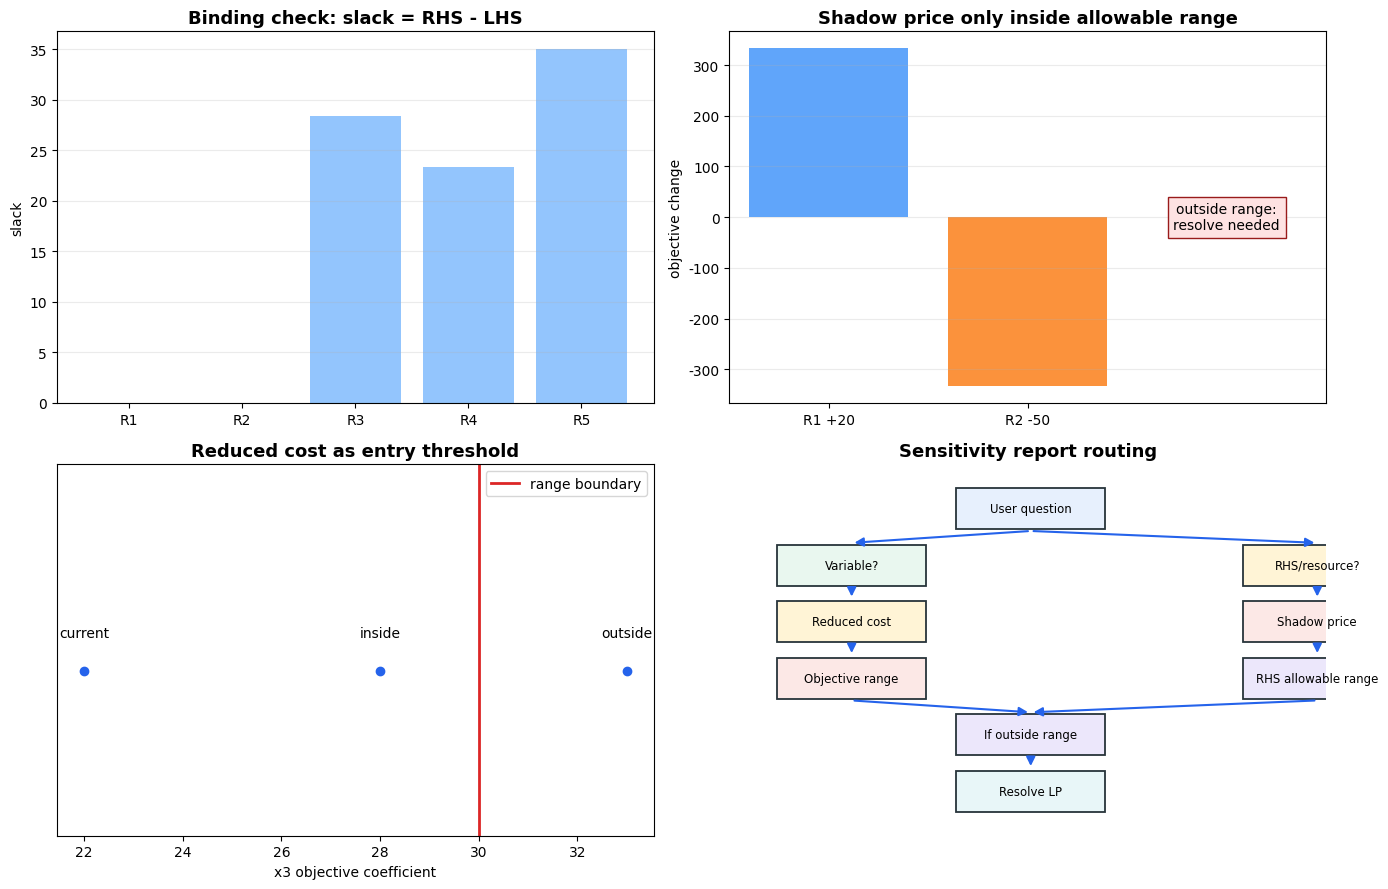

In [2]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0,0]
constraints = ["R1", "R2", "R3", "R4", "R5"]
rhs = np.array([100,120,55,70,35], dtype=float)
lhs = np.array([100,120,26.6667,46.6667,0], dtype=float)
slack = rhs - lhs
colors = ["#f87171" if s < 1e-6 else "#93c5fd" for s in slack]
ax.bar(constraints, slack, color=colors)
ax.set_title("Binding check: slack = RHS - LHS")
ax.set_ylabel("slack")
ax.grid(axis="y", alpha=0.25)

ax = axes[0,1]
labels = ["R1 +20", "R2 -50", "R1 +50"]
changes = [20*16.6667, -50*6.6667, np.nan]
ax.bar(labels[:2], changes[:2], color=["#60a5fa", "#fb923c"])
ax.text(2, 0, "outside range:\nresolve needed", ha="center", va="center", bbox=dict(fc="#fee2e2", ec="#991b1b"))
ax.set_xlim(-0.5, 2.5)
ax.set_title("Shadow price only inside allowable range")
ax.set_ylabel("objective change")
ax.grid(axis="y", alpha=0.25)

ax = axes[1,0]
profits = [22, 28, 33]
threshold = 22 + 8
ax.plot(profits, [0,0,0], "o", color="#2563eb")
ax.axvline(threshold, color="#dc2626", lw=2, label="range boundary")
ax.text(22, 0.04, "current", ha="center")
ax.text(28, 0.04, "inside", ha="center")
ax.text(33, 0.04, "outside", ha="center")
ax.set_ylim(-0.2, 0.25)
ax.set_yticks([])
ax.set_xlabel("x3 objective coefficient")
ax.set_title("Reduced cost as entry threshold")
ax.legend()

ax = axes[1,1]
ax.axis("off")
flow(ax, [
    ["User question"],
    ["Variable?", "RHS/resource?"],
    ["Reduced cost", "Shadow price"],
    ["Objective range", "RHS allowable range"],
    ["If outside range"],
    ["Resolve LP"]
], "Sensitivity report routing")

plt.tight_layout()
plt.show()


## 3. 채점 기준

- Variable Cells/Constraints 구분: 20점
- reduced cost와 shadow price 분리: 20점
- allowable range 적용: 25점
- binding/nonbinding 및 complementary slackness: 15점
- Solver mapping/source anchor/node_id: 10점
- 오답진단: 10점


## 4. 오답튜터 기준표

| 오류 | 피드백 기준 |
| --- | --- |
| shadow price를 무제한 적용 | allowable range 안에서만 적용된다고 교정한다. |
| reduced cost와 shadow price 혼동 | 변수 질문과 RHS 질문을 먼저 분리하게 한다. |
| nonbinding인데 shadow price 양수로 해석 | slack이 남으면 자원 추가 가치가 보통 0임을 설명한다. |
| objective coefficient 변화와 RHS 변화 혼동 | Variable Cells와 Constraints 섹션을 구분한다. |
| 범위 밖 변화 단정 | 재해찾기와 새 basis 필요성을 설명한다. |


## 5. 다음 Phase 연결

다음 Phase는 G3 transportation/network다. 수송문제에서는 경로별 수송량의 reduced cost와 공급/수요 제약의 shadow price가 같은 구조로 다시 등장한다.
